In [1]:
from xaikd import models, datasets, utils

from matplotlib import pyplot as plt

from torch.utils.data import random_split

from tqdm import tqdm 
import torch
import numpy as np

import scipy

In [2]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [3]:
def get_train_loaders():
    dataset_clean = datasets.construct("imagenet-butterfly")
    dataset_spurious = datasets.construct("imagenet-butterfly--spurious-threespurious--1.0")

    def _get_train_loader(dataset):
        rng = torch.Generator()
        rng.manual_seed(1)
        ds = dataset.create_subset(train_split=True)
        # ds, _ = random_split(ds, [0.1, 1 - 0.1], generator=rng)
        return datasets.build_dataloader(ds, shuffle=False)

    dl_trn_clean = _get_train_loader(dataset_clean)
    dl_trn_spr = _get_train_loader(dataset_spurious)

    # sanity check
    total_samples = 0
    for (x1, y_clean), (x2, y_spurious) in tqdm(
        zip(dl_trn_clean, dl_trn_spr), 
        desc="Sanity check 1"
    ):
                
        np.testing.assert_allclose(
            y_clean.numpy(),
            y_spurious.numpy()
        )
        selected = y_clean.numpy() %4 != 0
        if np.sum(selected) > 0:
            assert (
                (x1[selected] != x2[selected]).flatten(start_dim=1).sum(dim=1) > 0
            ).all()
        total_samples += y_clean.shape[0]
        
    for (x1, y_clean), (x2, y_clean2) in tqdm(
        zip(dl_trn_clean, _get_train_loader(dataset_clean)), 
        desc="Sanity check 2"
    ):
        np.testing.assert_allclose(
            y_clean.numpy(),
            y_clean2.numpy()
        )
        np.testing.assert_allclose(
            x1.numpy(),
            x2.numpy()
        )
    return dataset_clean, dataset_spurious, dl_trn_clean, dl_trn_spr, total_samples
dataset_clean, dataset_spurious, dl_trn_clean, dl_trn_spr, total_samples = get_train_loaders()

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|█████████████████████████████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 1090882.67it/s]


We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperclassWithThreeSpuriousFeatures[[321, 322, 323, 324, 325, 326]]` samples: 100%|████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 1057148.39it/s]
Sanity check 1: 122it [00:56,  2.14it/s]


We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|█████████████████████████████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 3222891.46it/s]
Sanity check 2: 122it [00:52,  2.30it/s]


In [4]:
total_samples

7800

In [5]:
@torch.no_grad()
def get_feature_map_difference_no_projection(
    model_name,
    arr_layers,
):

    n_layers = len(arr_layers) 
    arr_stats = list(map(lambda _: [], range(n_layers)))

    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset_clean.selected_classes)
    model.to(DEVICE)

    arr_ys = []
    for (x1, y1), (x2, y2) in tqdm(zip(dl_trn_clean, dl_trn_spr)):
        np.testing.assert_allclose(y1.cpu().numpy(), y2.cpu().numpy())

        _, arr_feat_x1 = utils.interceptor.forward_and_intercept_intermediate_layers(
            model=model,
            inp=x1.to(DEVICE),
            layers=arr_layers,
            detach_output=True
        )
        arr_feat_x1 = list(map(lambda f: f.cpu(), arr_feat_x1))
        arr_ys.extend(y2.numpy().tolist())
        
        _, arr_feat_x2 = utils.interceptor.forward_and_intercept_intermediate_layers(
            model=model,
            inp=x2.to(DEVICE),
            layers=arr_layers,
            detach_output=True
        )

        arr_feat_x2 = list(map(lambda f: f.cpu(), arr_feat_x2))


        for lix, (layer_feat_x1, layer_feat_x2) in enumerate(zip(arr_feat_x1, arr_feat_x2)):
            _, _, w, h = layer_feat_x1.shape

            

            layer_feat_x1 = layer_feat_x1.flatten(start_dim=1)
            layer_feat_x2 = layer_feat_x2.flatten(start_dim=1)
            norm = torch.linalg.norm(layer_feat_x1 - layer_feat_x2, dim=1) / (w*h)
            np.testing.assert_equal(norm.shape, y1.shape)
            np.testing.assert_equal(layer_feat_x1.shape, layer_feat_x2.shape)
    
            norm = norm.detach().cpu().numpy().tolist()
            arr_stats[lix].extend(norm)

    arr_stats = np.array(arr_stats)
    arr_ys = np.array(arr_ys)
    return arr_stats, arr_ys

_stats, _ys = get_feature_map_difference_no_projection(
    model_name="imagenet-resnet18-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"]
)

122it [01:01,  1.98it/s]


122it [01:00,  2.02it/s]


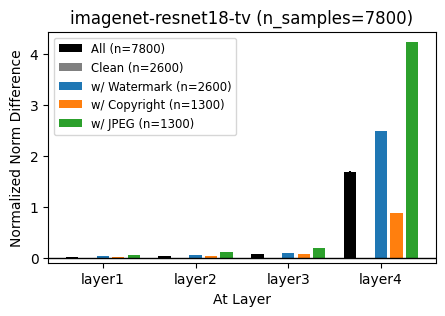

In [6]:
def layer_alias(name):
    return name.replace("features.", "feats.").replace("encoder.layers", "enclayer")
def viz_norm_difference(model_name, arr_layers):

    stats, ys = get_feature_map_difference_no_projection(
        model_name=model_name,
        arr_layers=arr_layers,
    )
    
    ncols = len(arr_layers)
    xticks = np.arange(ncols)
    
    plt.figure(figsize=(5, 3)) 
    plt.title(f"{model_name} (n_samples={total_samples})")
    
    plt.ylabel("Normalized Norm Difference")
    plt.xlabel("At Layer")
    mean = stats.mean(axis=1)
    sem = scipy.stats.sem(stats, axis=1)
    nsamples = stats.shape[1]
    
    plt.bar(6*xticks, mean, yerr=sem, label=f"All (n={nsamples})", color="black")
    arr_spurious_types = [
        "Clean",
        "w/ Watermark",
        "w/ Copyright",
        "w/ JPEG"
    ]
    for tix in range(4):
        label = arr_spurious_types[tix]
        selected = ys%4 == tix
        total = np.sum(selected)
        plt.bar(6*xticks + tix+1, stats[:, selected].mean(axis=1), color="gray" if tix == 0 else None, label=f"{label} (n={total})")
        
    plt.xticks(6*xticks + 2, list(map(layer_alias, arr_layers)))
    plt.ylim(bottom=-0.1)
    plt.axhline(0, ls="-", lw=1, color="k")
    plt.legend(fontsize="small")

viz_norm_difference(
    "imagenet-resnet18-tv",
    ["layer1", "layer2", "layer3", "layer4"]
)

122it [00:57,  2.13it/s]


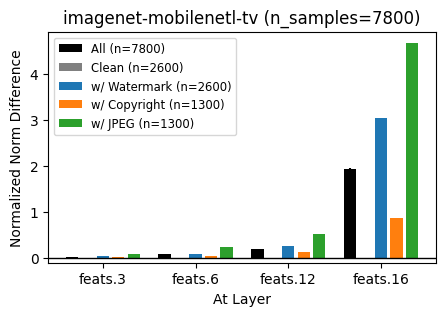

In [7]:
viz_norm_difference(
    "imagenet-mobilenetl-tv",
    ["features.3", "features.6", "features.12", "features.16"]
)

122it [01:35,  1.28it/s]


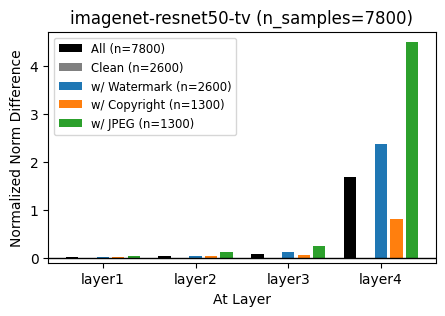

In [8]:

viz_norm_difference(
    "imagenet-resnet50-tv",
    ["layer1", "layer2", "layer3", "layer4"]
)

122it [01:39,  1.23it/s]


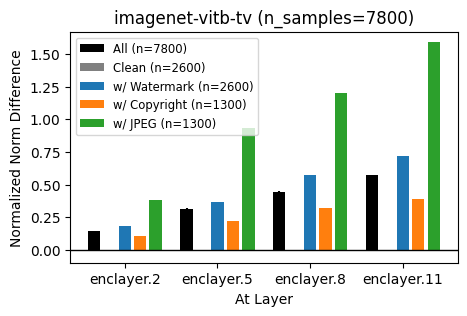

In [9]:
viz_norm_difference(
    "imagenet-vitb-tv",
    ["encoder.layers.2", "encoder.layers.5", "encoder.layers.8", "encoder.layers.11"]
)

122it [01:43,  1.18it/s]


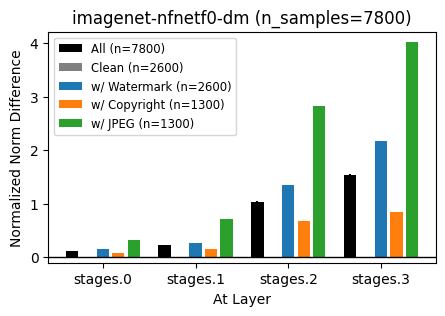

In [10]:
viz_norm_difference(
    "imagenet-nfnetf0-dm",
    ["stages.0", "stages.1", "stages.2", "stages.3"]
)